In [105]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import shapely
import numpy as np
import fiona

# packages from princeton gerrymetrics project
# github source: https://github.com/PrincetonUniversity/gerrymandertests
import gerrymetrics as g
import IPython.display as ipd
from collections import defaultdict

%matplotlib inline
%config InlineBackend.figure_format = "retina"

# states whos districting map changes 118-119: Alabama, Georgia, Louisiana, New York, and North Carolina

In [33]:
# congressional district boundaries CONG118 data set: https://redistrictingdatahub.org/dataset/118th-congressional-districts-nov-2022-election-active-jan-2023-jan-2025/
dists_map_8 = gpd.read_file("data/CONG118/national_cong118_carto_boundary.shp", engine="fiona")

# congressional district boundaries CONG119 data set: https://redistrictingdatahub.org/dataset/119th-congressional-districts-and-block-assignment-file-nov-2024-election-active-jan-2025-jan-2027/
dists_map = gpd.read_file("data/CONG119/national_cong119_carto_boundary.shp", engine="fiona")

# congressional district demographic information data set: https://redistrictingdatahub.org/dataset/119th-congress-district-level-data-demographic-economic-language-and-partisan/
dists_info = gpd.read_file("data/CONG119/national_cong119_district_data.csv", engine="fiona")

In [34]:
# shorten column names for demographic info
demo_dict = {
    'CONG119': 'CONG119',
    'STATE': 'STATE',
    'DISTRICT': 'DISTRICT', 
    'TOTPOP20': 'TOT_POP', 
    'NH White': 'WHITE',
    'NH Black plus NH Black and White': 'BLACK', 
    'NH Asian plus NH Asian and White': 'ASIAN',
    'NH American Indian plus NH American Indian and White': 'AMERIN',
    'NH Pacific Islander plus NH Pacific Islander and White': 'PACIS',
    'NH Some Other Race plus NH Some Other Race and White': 'OTHER',
    'NH Other multiple-race': 'MULTI', 
    'Hispanic': 'HISPANIC', 
    'TOT_HOUS22_est': 'TOT_HOUSE',
    'LESS_10K22_est': 'LESS_10K', 
    '10K_15K22_est': '10K_15K', 
    '15K_20K22_est': '15K_20K', 
    '20K_25K22_est': '20K_25K',
    '25K_30K22_est': '25K_30K',
    '30K_35K22_est': '30K_35K', 
    '35K_40K22_est': '35K_40K', 
    '40K_45K22_est': '40K_45K',
    '45K_50K22_est': '45K_50K', 
    '50K_60K22_est': '50K_60K', 
    '60K_75K22_est': '60K_75K', 
    '75K_100K22_est': '75K_100K',
    '100_125K22_est': '100K_125K', 
    '125_150K22_est': '125K_150K', 
    '150_200K22_est': '150K_200K', 
    '200K_MOR22_est': 'OVER_200K',
    'Median_HH_Income_Est': 'MED_HH_INC', 
    'BACH_PLUS_pct': 'BACH', 
    'FOREIGN_BORN_pct': 'FOREIGN',
    'ENG_LW_pct': 'ENG_LW', 
    'Total_20_Pres_Votes_Est': 'TOT_VOTES', 
    'G20PREDBID_pct': 'BIDEN',
    'G20PRELJOR_pct': 'JORGENSEN', 
    'G20PRERTRU_pct': 'TRUMP'
}

# rename columns and drop repeated columns
dists_info = dists_info.rename(columns = demo_dict)
dists_info["BIDEN"] = pd.to_numeric(dists_info["BIDEN"])
dists_demo = dists_info.drop(columns = ["STATE", "DISTRICT"])

# make data set with shp data and demographic data
dists = dists_map.merge(dists_demo, on = "CONG119", how = "left")

# divide district data for each state into separate dfs
states = [
    "AK", "AL", "AR", "AZ", "CA", "CO", "CT", "DE", "FL", "GA", "HI", "IA",
    "ID", "IL", "IN", "KS", "KY", "LA", "MA", "MD", "ME", "MI", "MN", "MO",
    "MS", "MT", "NC", "ND", "NE", "NH", "NJ", "NM", "NV", "NY", "OH", "OK",
    "OR", "PA", "RI", "SC", "SD", "TN", "TX", "UT", "VA", "VT", "WA", "WI",
    "WV", "WY"
]

for state in states:
    globals()[state] = dists[dists["STATE"] == state]


# repeat these processes for cong118 data
dists_demo_8 = dists_demo.copy()
dists_demo_8.rename(columns = {"CONG119": "CONG118"}, inplace = True)
dists_demo_8.head()
dists_8 = dists_map_8.merge(dists_demo_8, on = "CONG118", how = "left")

for state in states:
    globals()[state + "_8"] = dists_8[dists_8["STATE"] == state]

In [68]:
# functions to compute and plot convex hull
# input state, district number
def comp_hull(state, d):
    if d in range(1,10):
        i = "0" + str(d)
    else:
        i = str(d)
    dist = state[state["DISTRICT"] == i]
    hull = dist.convex_hull
    #hull_crs = hull.geometry.to_crs("epsg:32633")
    return(hull)

# plot convex hull
def plot_hull(state, d):
    hull = comp_hull(state, d)
    hull.plot(figsize = (10,10))

# compute region of convex hull outside of the district
def hull_overlap(state, d):
    if d in range(1,10):
        i = "0" + str(d)
    else:
        i = str(d)
    dist = state[state["DISTRICT"] == i]
    hull = dist.convex_hull
    overlap = hull.difference(dist)
    return(overlap)

# plot region of convex hull outside of district
def plot_overlap(state, d):
    overlap = hull_overlap(state, d)
    overlap.plot(figsize = (10,10))

# compute region of convex hull outside of district but within state lines
def hull_intersection(state, d):
    hull = hull_overlap(state, d)
    hull_df = gpd.GeoDataFrame(geometry = hull)
    intersection = gpd.overlay(state, hull_df, how="intersection", keep_geom_type = True)
    return(intersection)

# plot region of convex hull outside of district but within state lines
def plot_intersection(state, d):
    intersection = hull_intersection(state, d)
    intersection.plot(figsize = (10, 10))

# compute area of convex hull outside of district but within state lines
def hull_area(state, d):
    hull_pts = hull_intersection(state, d)
    hull = sum(hull_pts.geometry.to_crs("epsg:32633").area)
    return(hull)

# compute ratio of area of convex hull outside of district but within state lines to area of district
# idea: higher ratio implies that the district is less convex
# this function is unnecessary now, because these values can be accessed in a state's df, but could be useful for finding values for single districts
def hull_ratio(state, d):
    if d in range(1,10):
        i = "0" + str(d)
    else:
        i = str(d)
    dist = state[state["DISTRICT"] == i]["geom.crs"].area
    hull = hull_area(state, d)
    ratio = hull / dist
    return(ratio)

In [ ]:
# add columns to each state's df
# adds rows to state dfs with the crs adjusted geometry data and district area
for state in states:
    globals()[state]["geom_crs"] = globals()[state].loc[:, "geometry"].geometry.to_crs("epsg:32633")
    globals()[state]["area"] = globals()[state].loc[:, "geom_crs"].area

# compute hull areas for all districts in a given state and add to df
for state in states:
    col = []
    s = globals()[state]
    for d in range(1, len(s) + 1):
        val = hull_area(s, d)
        col.append(val)
    globals()[state]["hull_area"] = col
    globals()[state]["hull_ratio"] = globals()[state]["hull_area"] / globals()[state]["area"]  

In [4]:
# function to plot cong118 and cong119 side by side
# input = string of state code
def plot_comp(state):
    # establish state
    STATE = globals()[state]
    STATE_8 = globals()[state + "_8"]
    
    # create figure
    fig, (ax_8, ax_9) = plt.subplots(nrows=1, ncols=2, figsize=(14, 7))

    # create cong118 map
    STATE_8.plot(ax=ax_8, column="BIDEN", cmap="RdBu", edgecolor="black")
    ax_8.set_title("CONG118", fontsize=14)
    ax_8.axis("off") 

    # create cong119 map
    STATE.plot(ax=ax_9, column="BIDEN", cmap="RdBu", edgecolor="black")
    ax_9.set_title("CONG119", fontsize=14)
    ax_9.axis("off") 

    # adjust spacing and display figure
    plt.tight_layout()
    plt.show()

# HOW IS CONG118 GETTING COLORED????
# fixed coloring for cong119, need to find data set for cong118
# colored cong118 using the same data as for cong119 - i think neither is actually accurate, but im not sure it matters that much because its just kinds vibes 
# would be interesting to see the actual total color changes, but perhaps not reasonable data to collect

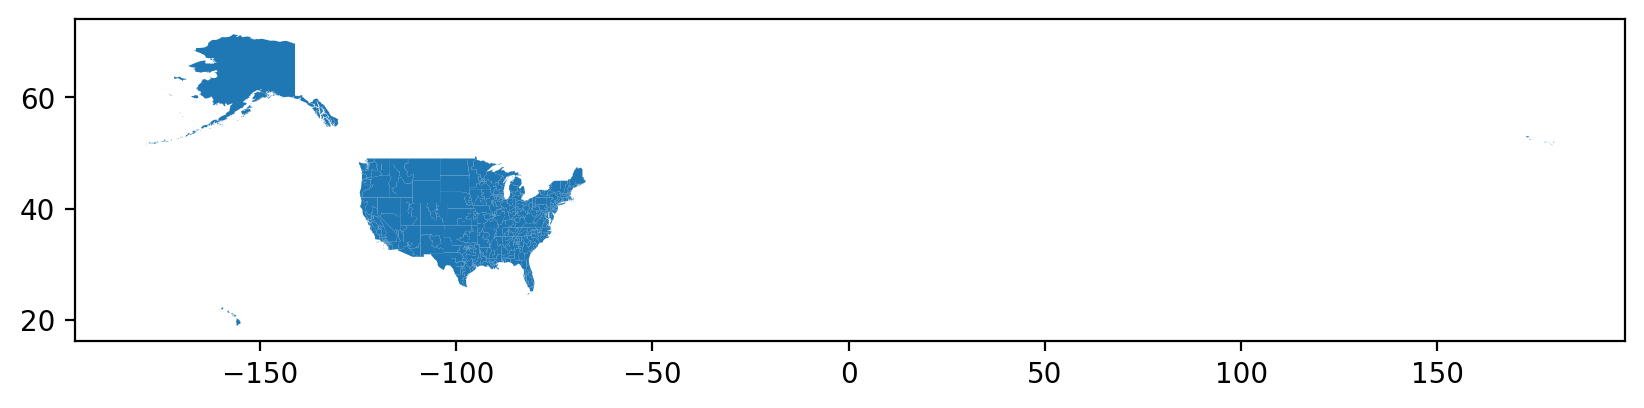

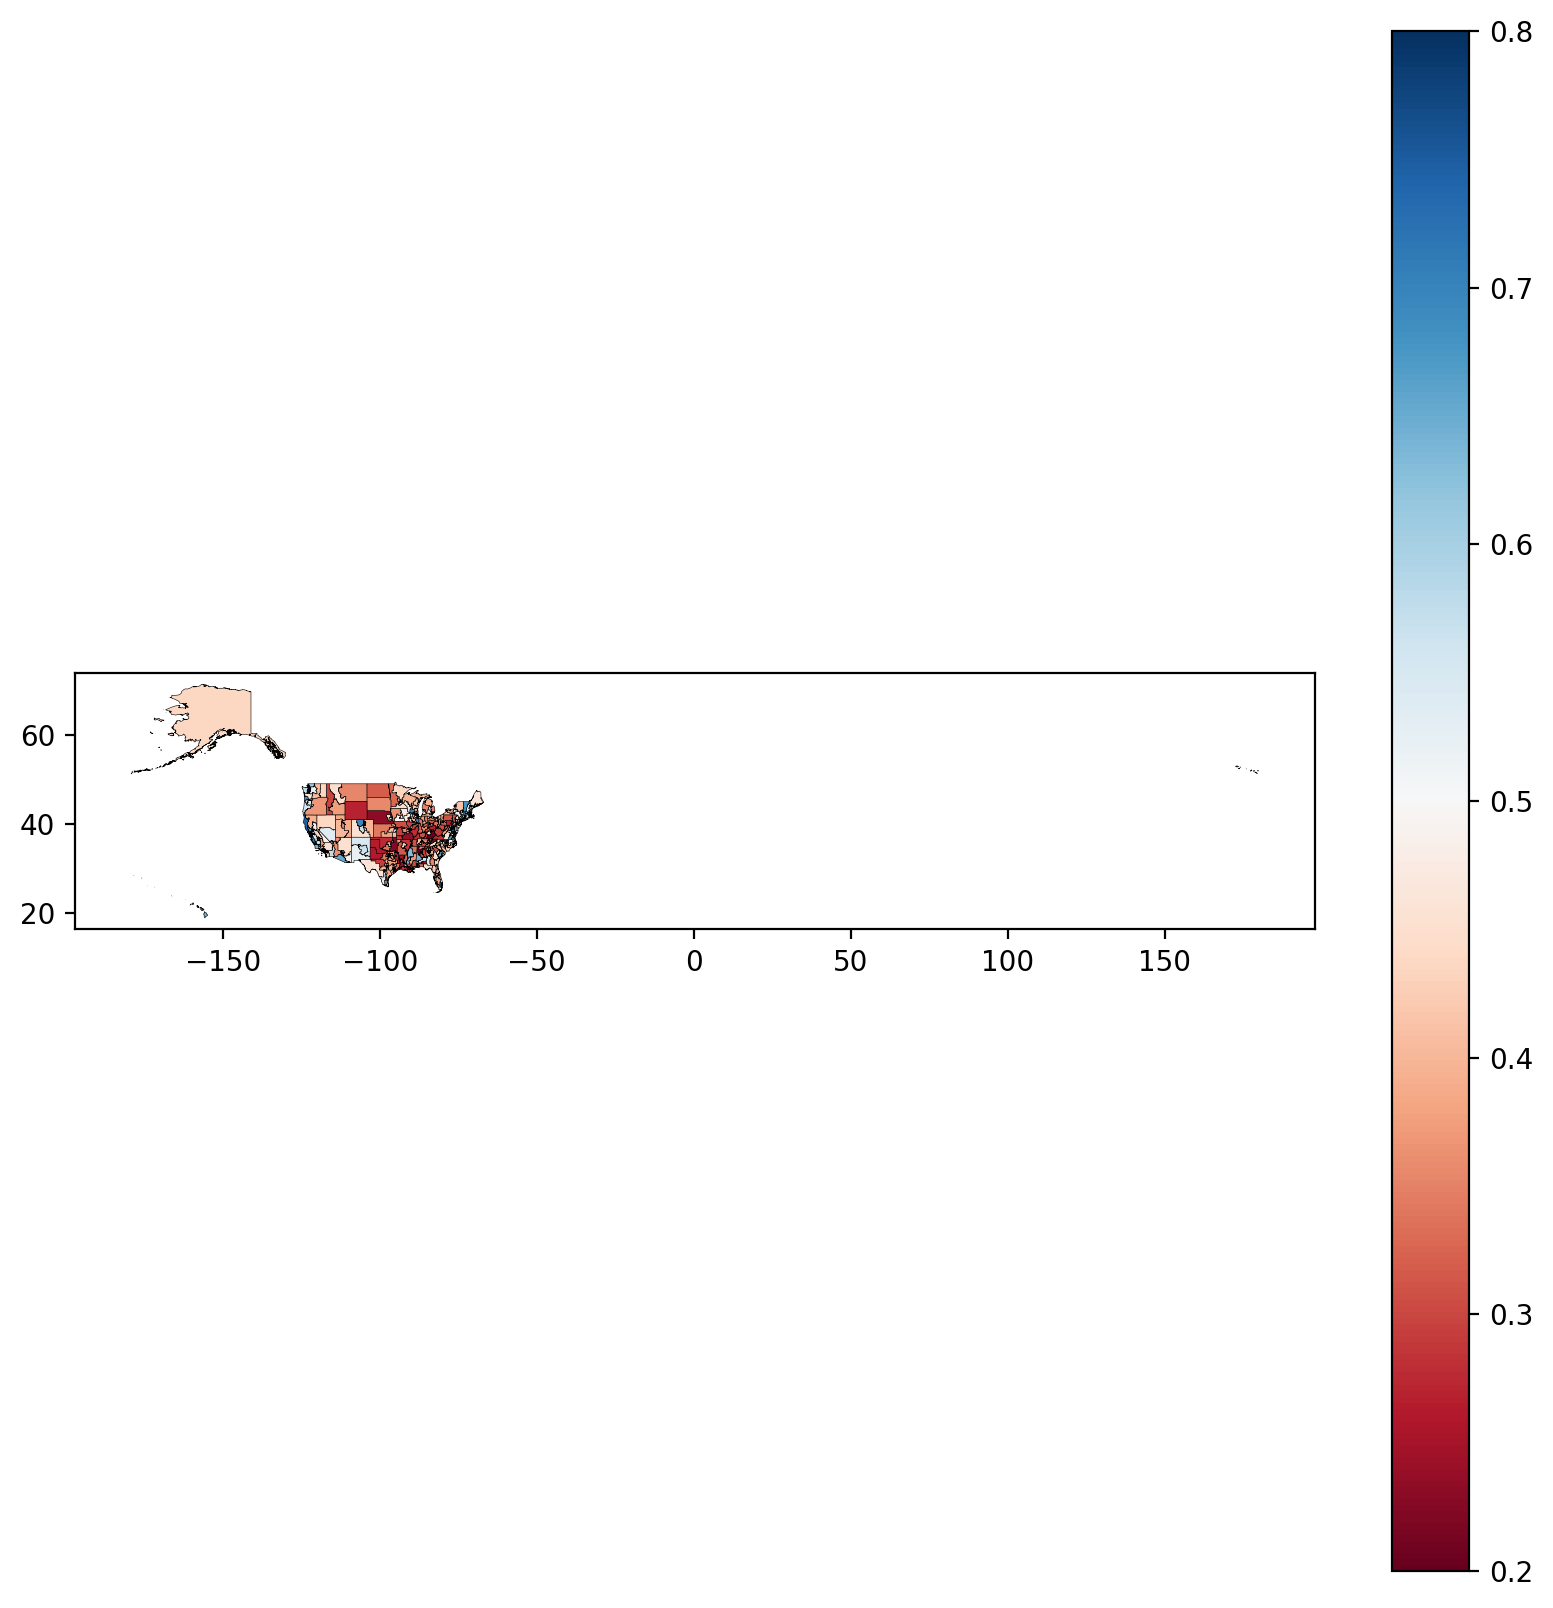

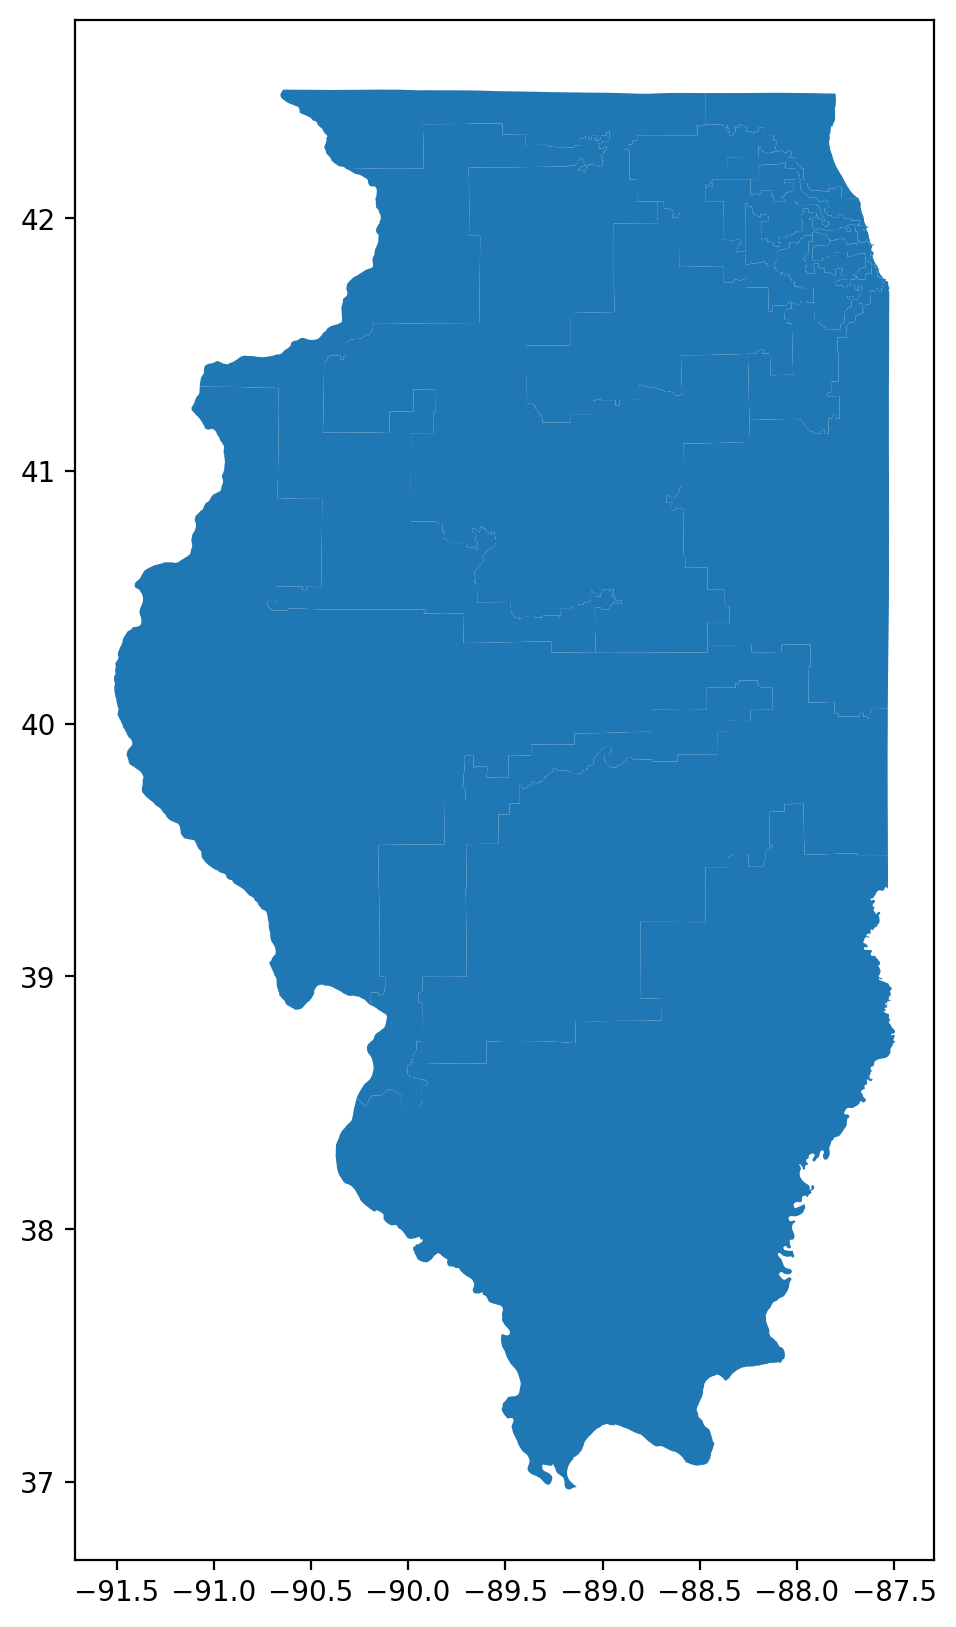

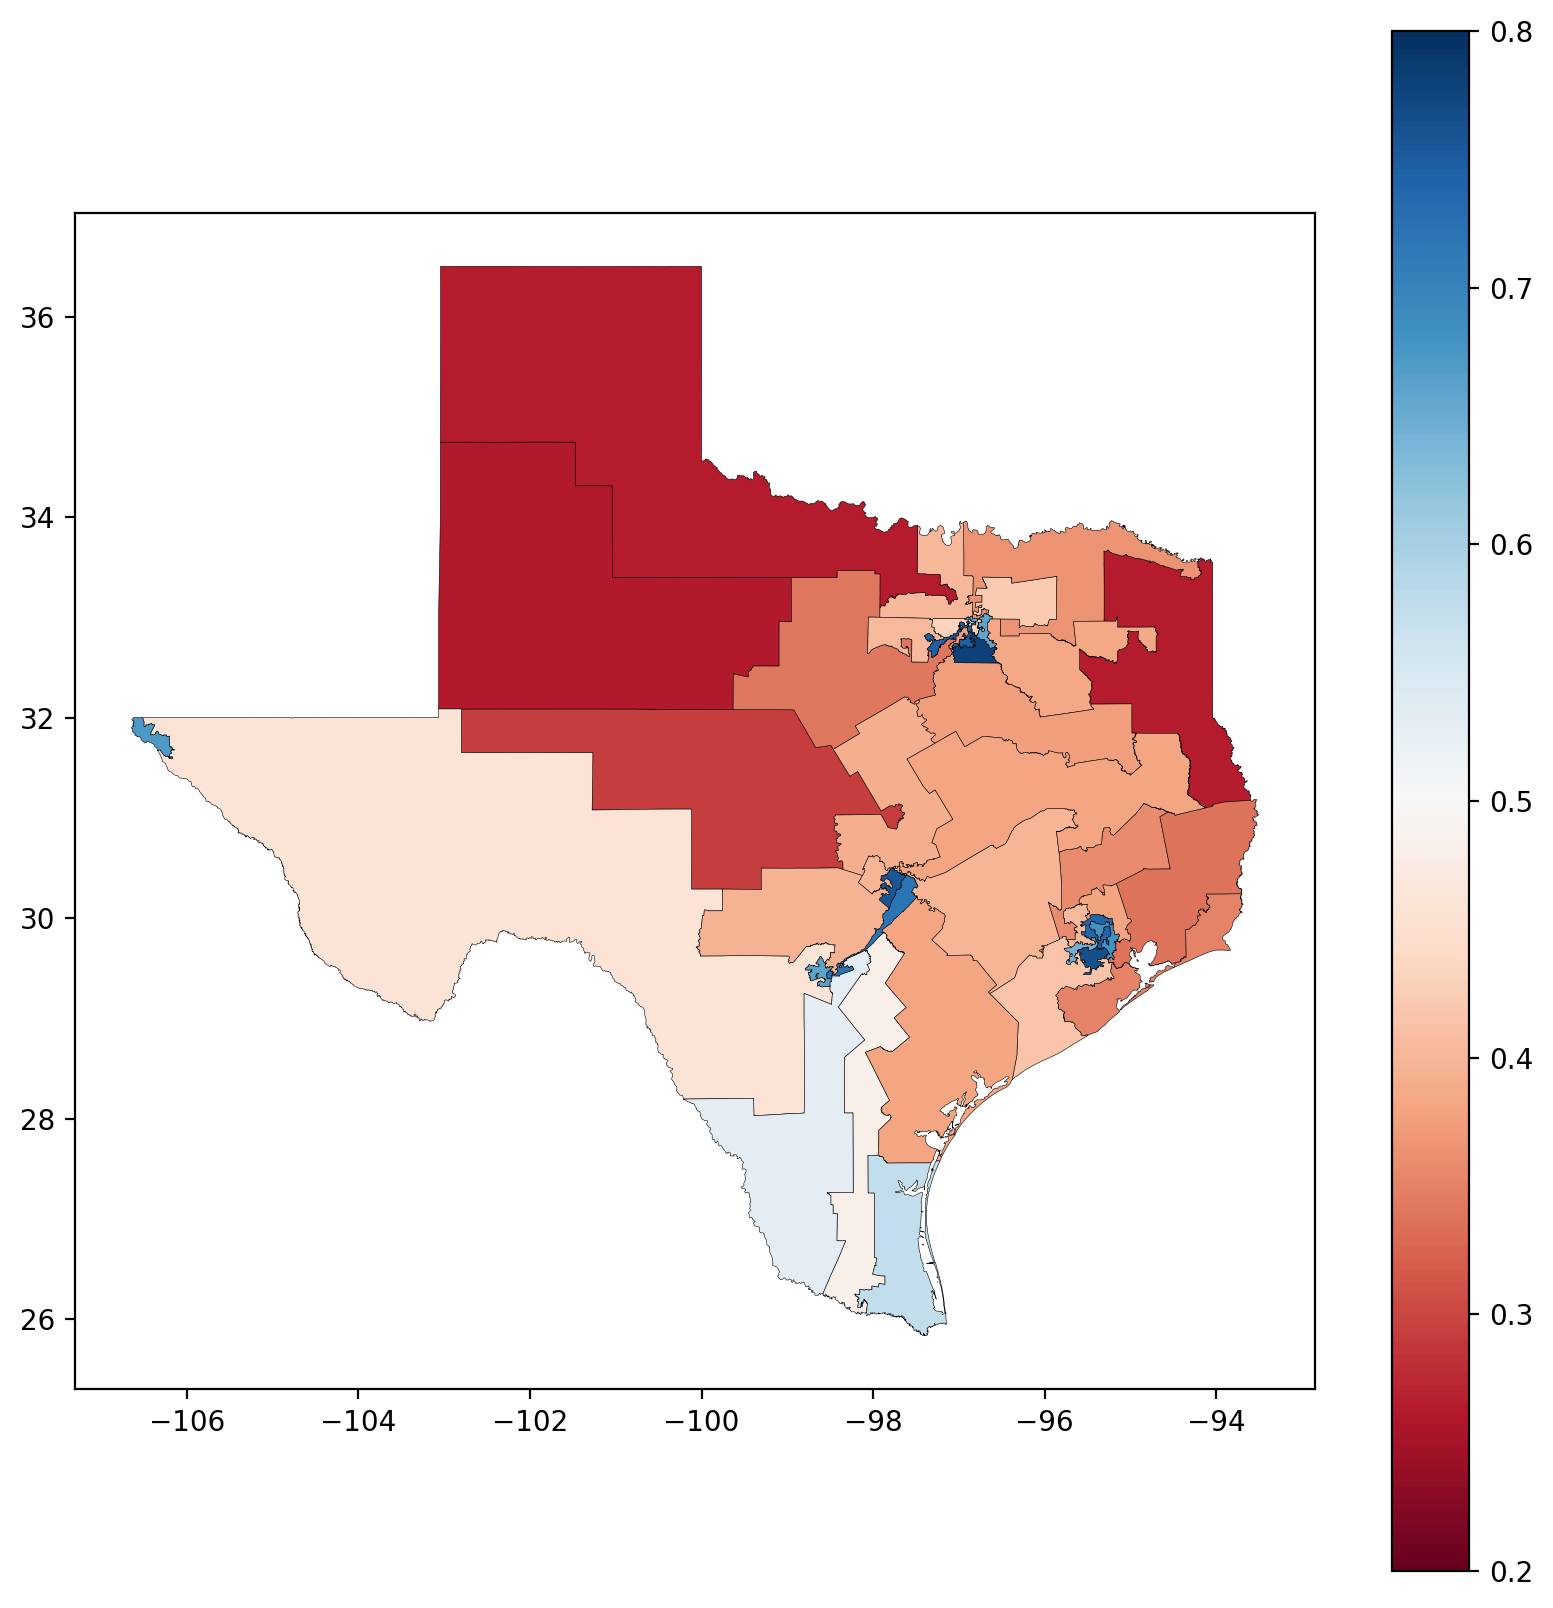

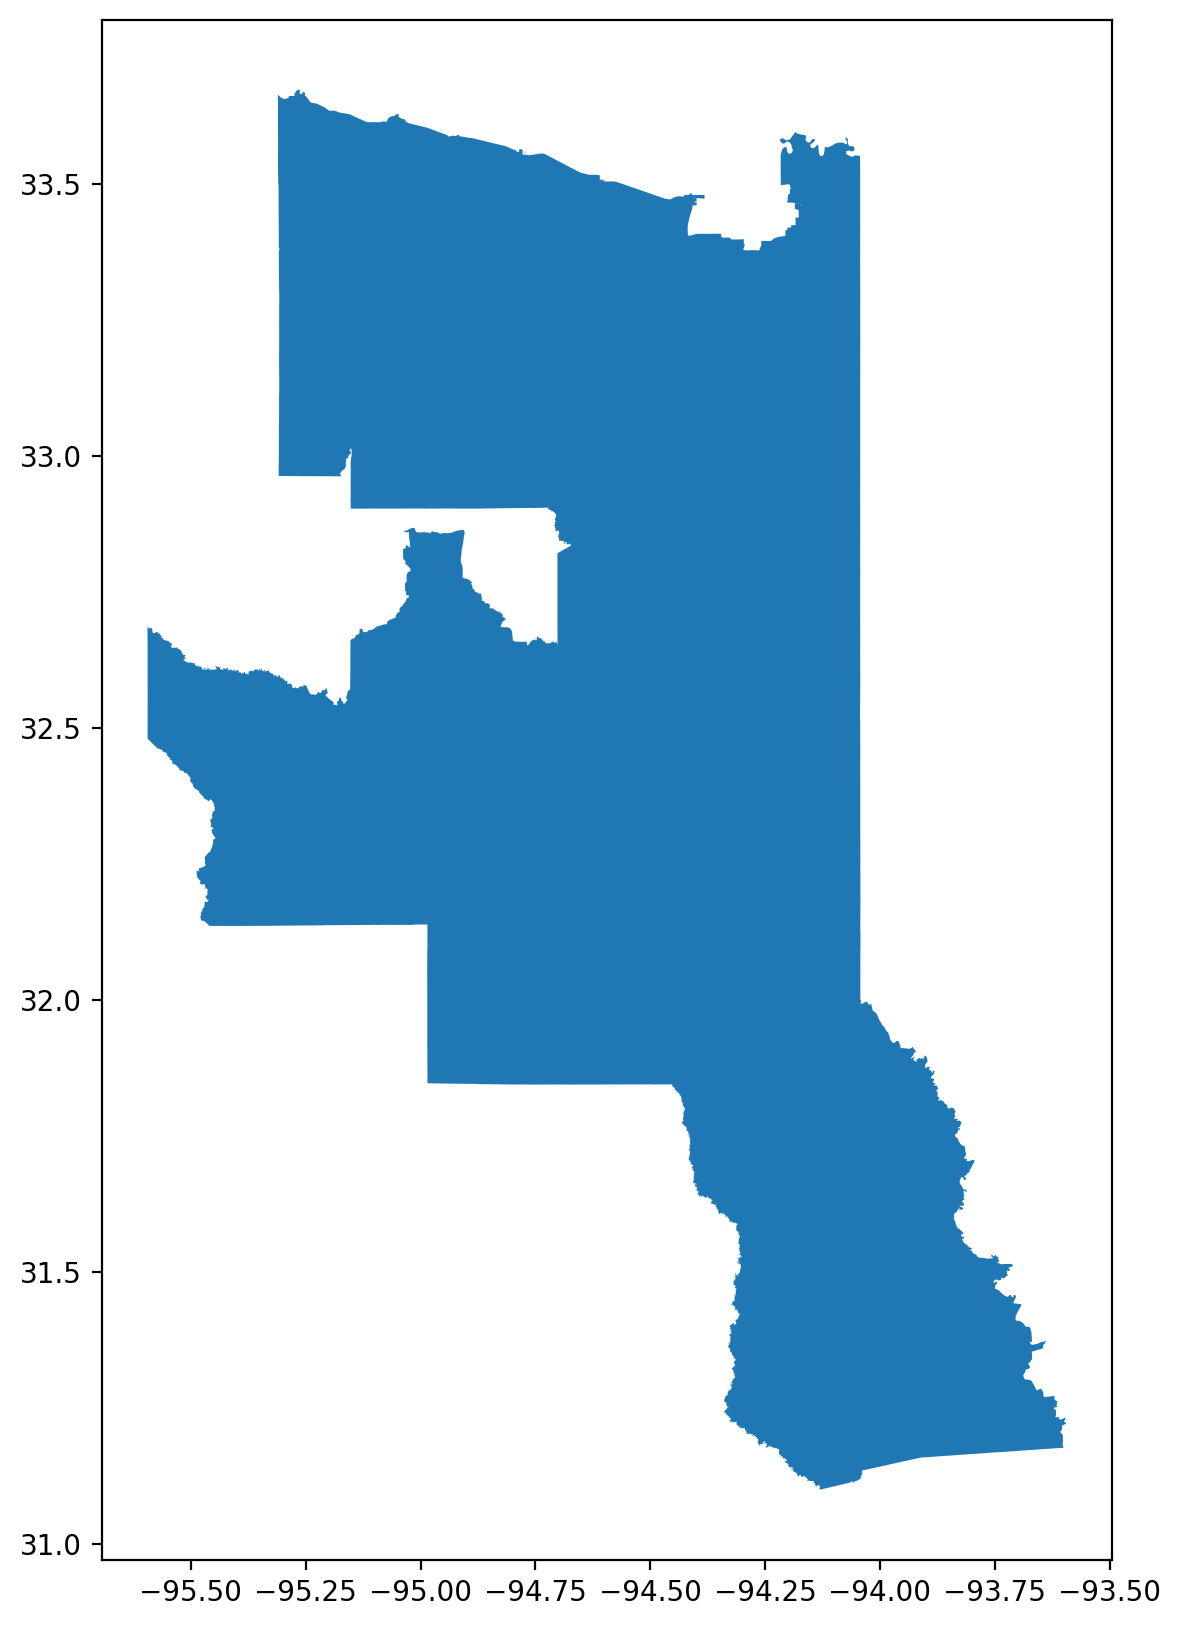

In [6]:
# plot shortcuts
# plot full image
dists.plot(figsize=(10, 10));

# plot fill image with coloring
dists.plot(
    column="BIDEN",
    legend=True,
    figsize=(10, 10),
    edgecolor="black",
    linewidth=0.2,
    cmap = "RdBu",
    vmin = 0.20,
    vmax = 0.80
);

# plot single state
IL.plot(figsize = (10, 10));

# plot single state with coloring
TX.plot(
    column="BIDEN",
    legend=True,
    figsize=(10, 10),
    edgecolor="black",
    linewidth=0.2,
    cmap = "RdBu",
    vmin = 0.20,
    vmax = 0.80
);

# plot single district
TX_1 = TX[TX["DISTRICT"] == "01"]
TX_1.plot(figsize = (10, 10));

In [10]:
# computing convex hull, ratio of convex hull area to district area
# input state, district number
# compute convex hull
# state should not be a string, d should be a string
# CAN I STREAMLINE THIS ENTRY?
def comp_hull(state, d):
    dist = state[state["DISTRICT"] == d]
    hull = dist.convex_hull
    return(hull)

# plot convex hull
def plot_hull(state, d):
    hull = comp_hull(state, d)
    hull.plot(figsize = (10,10))

# compute area of convex hull outside of the district
def hull_overlap(state, d):
    dist = state[state["DISTRICT"] == d]
    hull = dist.convex_hull
    overlap = hull.difference(dist)
    return(overlap)

def plot_overlap(state, d):
    overlap = hull_overlap(state, d)
    overlap.plot(figsize = (10,10))

def hull_intersection(state, d):
    hull = hull_overlap(state, d)
    hull_df = gpd.GeoDataFrame(geometry = hull)
    intersection = gpd.overlay(state, hull_df, how="intersection", keep_geom_type = True)
    return(intersection)

def plot_intersection(state, d):
    intersection = hull_intersection(state, d)
    intersection.plot(figsize = (10, 10))

def hull_area(state, d):
    hull_pts = hull_intersection(state, d)
    hull = hull_pts.area
    return(hull)

# compute ratio
def hull_ratio(state, d):
    dist = state[state["DISTRICT"] == d].area.iloc[0]
    hull = hull_area(state, d).iloc[0]
    ratio = hull / dist
    return(ratio)
